In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [2]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               348 non-null    object 
 1   Step                    348 non-null    object 
 2   Input Tokens (Prompt)   348 non-null    int64  
 3   Output Tokens (Answer)  348 non-null    int64  
 4   Total Tokens            348 non-null    int64  
 5   Latency (s)             348 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 16.4+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
count,348.000000,348.000000,348.000000,348.000000
mean,8771.554598,202.221264,9676.333333,3.670489
std,11204.025815,472.203077,12523.063177,7.477740
min,477.000000,3.000000,640.000000,0.590000
25%,754.000000,15.000000,1084.750000,0.937500
50%,1294.500000,72.000000,1877.000000,1.380000
75%,26368.750000,292.000000,26484.000000,4.540000
max,34670.000000,7611.000000,55642.000000,81.070000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79


In [3]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens',
    'Latency (s)': 'Latency'
})

df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if '_Naive' in x else 'FRB' if '_FRB' in x else 'HRB')

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens,Latency,Extra Tokens,Model
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28,0,HRB
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67,775,HRB
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82,0,HRB
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33,192,FRB
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79,0,FRB


In [4]:
step_token_usage_df = df.groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].mean().reset_index() 
display(step_token_usage_df)
step_time_usage_df = df.groupby(['Step', 'Model'])['Latency'].mean().reset_index()
display(step_time_usage_df)

model_token_usage_df = step_token_usage_df.groupby('Model')[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].sum().reset_index()
display(model_token_usage_df)
model_time_usage_df = step_time_usage_df.groupby('Model')['Latency'].sum().reset_index()
display(model_time_usage_df)

,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,Evaluator_FRB,FRB,1330.577778,60.022222,0.044444,1390.644444
1,Evaluator_HRB,HRB,1246.121951,58.317073,0.000000,1304.439024
2,Evaluator_Naive,Naive,27420.244444,55.977778,0.311111,27476.533333
3,Generator_FRB,FRB,944.088889,472.733333,524.355556,1941.177778
4,Generator_HRB,HRB,865.512195,443.609756,501.682927,1810.804878
5,Generator_Naive,Naive,26876.955556,496.711111,4448.511111,31822.177778
6,Router_FRB,FRB,748.155556,12.688889,1.822222,762.666667
7,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927


,Step,Model,Latency
0,Evaluator_FRB,FRB,1.063556
1,Evaluator_HRB,HRB,1.008293
2,Evaluator_Naive,Naive,3.139333
3,Generator_FRB,FRB,5.745556
4,Generator_HRB,HRB,5.944390
5,Generator_Naive,Naive,10.177333
6,Router_FRB,FRB,0.993333
7,Router_HRB,HRB,1.022195


,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,FRB,3022.822222,545.444444,526.222222,4094.488889
1,HRB,11539.024390,511.146341,502.756098,12552.926829
2,Naive,54297.200000,552.688889,4448.822222,59298.711111


,Model,Latency
0,FRB,7.802444
1,HRB,7.974878
2,Naive,13.316667


In [5]:
model_analysis = model_token_usage_df.merge(model_time_usage_df.set_index('Model'), left_on='Model', right_index=True)
display(model_analysis)

step_analysis = step_token_usage_df.merge(step_time_usage_df.set_index('Step'), left_on='Step', right_index=True)
display(step_analysis)

model_analysis.to_csv('analysis/model_analysis.csv', index=False)
step_analysis.to_csv('analysis/step_analysis.csv', index=False)

,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,FRB,3022.822222,545.444444,526.222222,4094.488889,7.802444
1,HRB,11539.024390,511.146341,502.756098,12552.926829,7.974878
2,Naive,54297.200000,552.688889,4448.822222,59298.711111,13.316667


,Step,Model_x,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Model_y,Latency
0,Evaluator_FRB,FRB,1330.577778,60.022222,0.044444,1390.644444,FRB,1.063556
1,Evaluator_HRB,HRB,1246.121951,58.317073,0.000000,1304.439024,HRB,1.008293
2,Evaluator_Naive,Naive,27420.244444,55.977778,0.311111,27476.533333,Naive,3.139333
3,Generator_FRB,FRB,944.088889,472.733333,524.355556,1941.177778,FRB,5.745556
4,Generator_HRB,HRB,865.512195,443.609756,501.682927,1810.804878,HRB,5.944390
5,Generator_Naive,Naive,26876.955556,496.711111,4448.511111,31822.177778,Naive,10.177333
6,Router_FRB,FRB,748.155556,12.688889,1.822222,762.666667,FRB,0.993333
7,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927,HRB,1.022195


In [6]:
chat_df = pd.read_csv('chat_logs.csv')
topic_subtopic_per_architecture_df = chat_df.groupby('Architecture').agg({
    'Topic_Count': 'mean',
    'Subtopic_Count': 'mean'
}).reset_index()

display(topic_subtopic_per_architecture_df)
chat_df.to_csv('analysis/chat_analysis.csv', index=False)

,Architecture,Topic_Count,Subtopic_Count
0,FRB,2.073171,14.585366
1,HRB,1.243902,8.902439
2,Naive,117.911111,1030.155556


## Plots

### Cmap

In [7]:
# Colormap for each Step category

FRB = "#1F77B4"
HRB = "#328F3A"
full_db = "#f93e3e"

step_cmap = {
    'Router_FRB': FRB,
    'Generator_FRB': FRB,
    'Evaluator_FRB': FRB,

    'Router_HRB': HRB,
    'Generator_HRB': HRB,
    'Evaluator_HRB': HRB,

    'Generator_Naive': full_db,
    'Evaluator_Naive': full_db
}

model_cmap = {
    'FRB': FRB,
    'HRB': HRB,
    'Naive': full_db
}

### Comparison

#### Average token per model

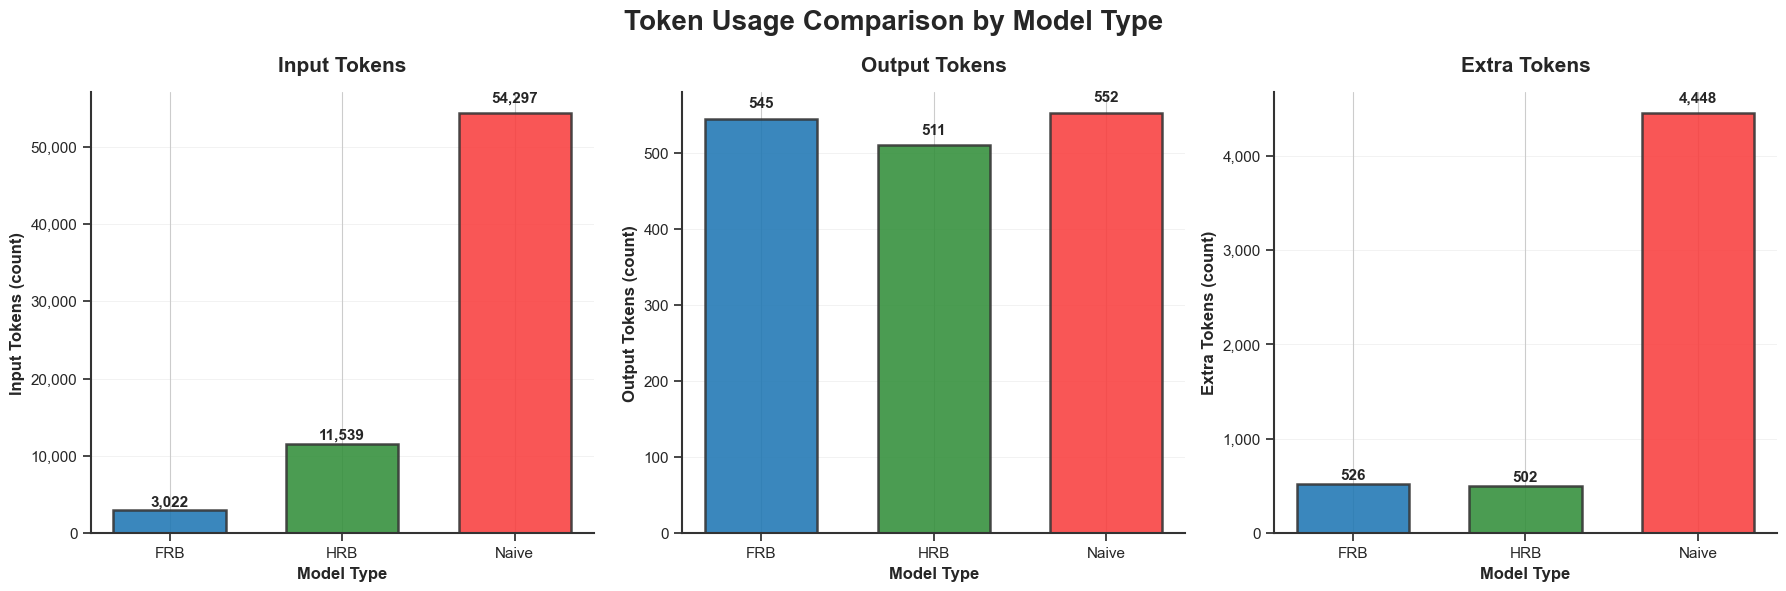

In [8]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    
    bars = ax.bar(model_token_usage_df['Model'], model_token_usage_df[metric], 
                   color=[model_cmap[model] for model in model_token_usage_df['Model']],
                   edgecolor='#333333', linewidth=1.8, alpha=0.88, width=0.65)
    
    ax.set_title(f'{metric}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel(f'{metric} (count)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Improve tick labels
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)
    ax.tick_params(axis='y', which='minor', labelsize=10)
    
    # Format y-axis with thousand separators
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Add value labels on bars with better formatting
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.02,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

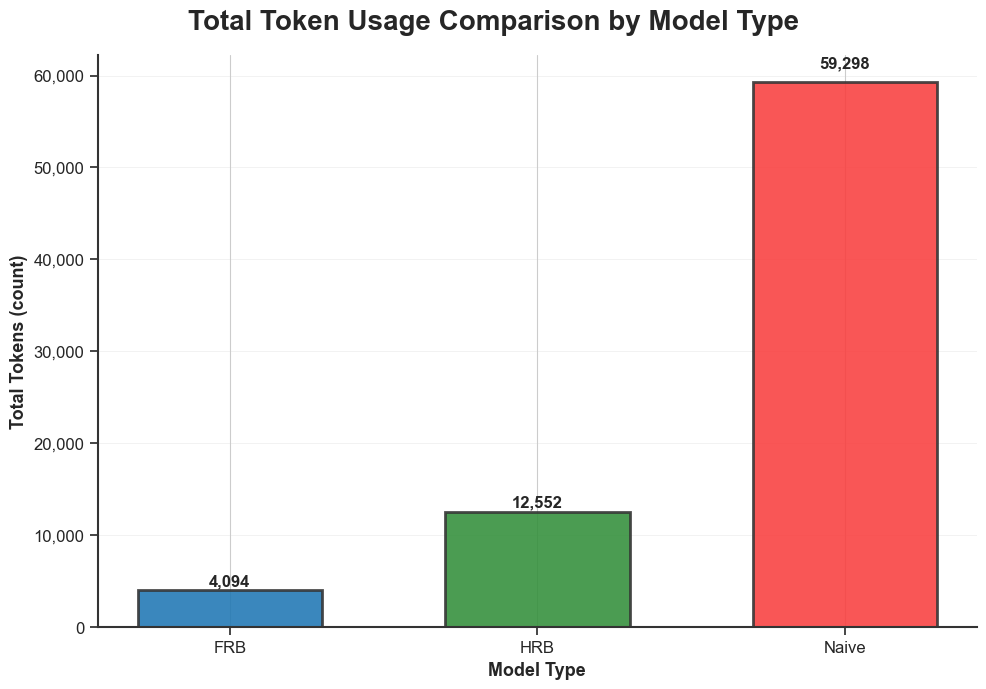

In [9]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_token_usage_df['Model'],
    model_token_usage_df['Total Tokens'],
    color=[model_cmap[model] for model in model_token_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Tokens (count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

# Format y-axis with thousand separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        #family='serif'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

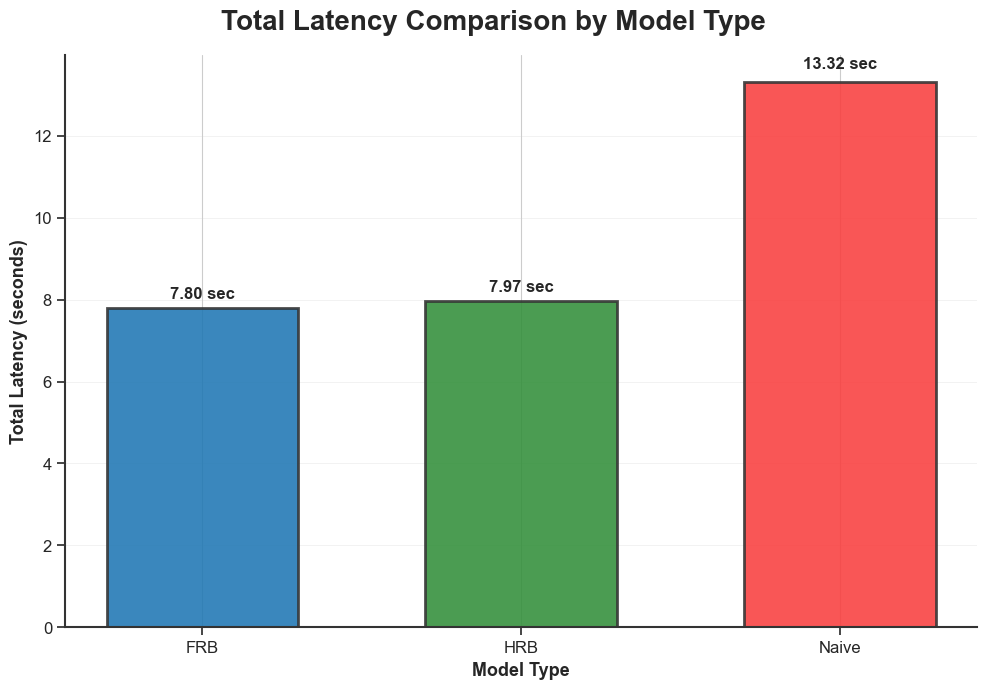

In [10]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Latency Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_time_usage_df['Model'],
    model_time_usage_df['Latency'],
    color=[model_cmap[model] for model in model_time_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Latency (seconds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{height:.2f} sec',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

In [11]:
print(df['Step'].value_counts())
print('\n')
print(df['Model'].value_counts())

Step
Generator_FRB      45
Evaluator_FRB      45
Router_FRB         45
Generator_Naive    45
Evaluator_Naive    45
Router_HRB         41
Generator_HRB      41
Evaluator_HRB      41
Name: count, dtype: int64


Model
FRB      135
HRB      123
Naive     90
Name: count, dtype: int64


In [12]:
router_usage_df = df[df['Step'].str.contains('Router')].groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']].mean().reset_index()
display(router_usage_df)
router_usage_df.to_csv('analysis/router_usage.csv', index=False)
router_usage_df = router_usage_df.merge(topic_subtopic_per_architecture_df.set_index('Architecture'), left_on='Model', right_index=True)
display(router_usage_df)

generator_usage_df = df[df['Step'].str.contains('Generator')].groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']].mean().reset_index()
display(generator_usage_df)
generator_usage_df.to_csv('analysis/generator_usage.csv', index=False)

evaluator_usage_df = df[df['Step'].str.contains('Evaluator')].groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']].mean().reset_index()
display(evaluator_usage_df)
evaluator_usage_df.to_csv('analysis/evaluator_usage.csv', index=False)


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,Router_FRB,FRB,748.155556,12.688889,1.822222,762.666667,0.993333
1,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927,1.022195


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency,Topic_Count,Subtopic_Count
0,Router_FRB,FRB,748.155556,12.688889,1.822222,762.666667,0.993333,2.073171,14.585366
1,Router_HRB,HRB,9427.390244,9.219512,1.073171,9437.682927,1.022195,1.243902,8.902439


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,Generator_FRB,FRB,944.088889,472.733333,524.355556,1941.177778,5.745556
1,Generator_HRB,HRB,865.512195,443.609756,501.682927,1810.804878,5.944390
2,Generator_Naive,Naive,26876.955556,496.711111,4448.511111,31822.177778,10.177333


,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Latency
0,Evaluator_FRB,FRB,1330.577778,60.022222,0.044444,1390.644444,1.063556
1,Evaluator_HRB,HRB,1246.121951,58.317073,0.000000,1304.439024,1.008293
2,Evaluator_Naive,Naive,27420.244444,55.977778,0.311111,27476.533333,3.139333


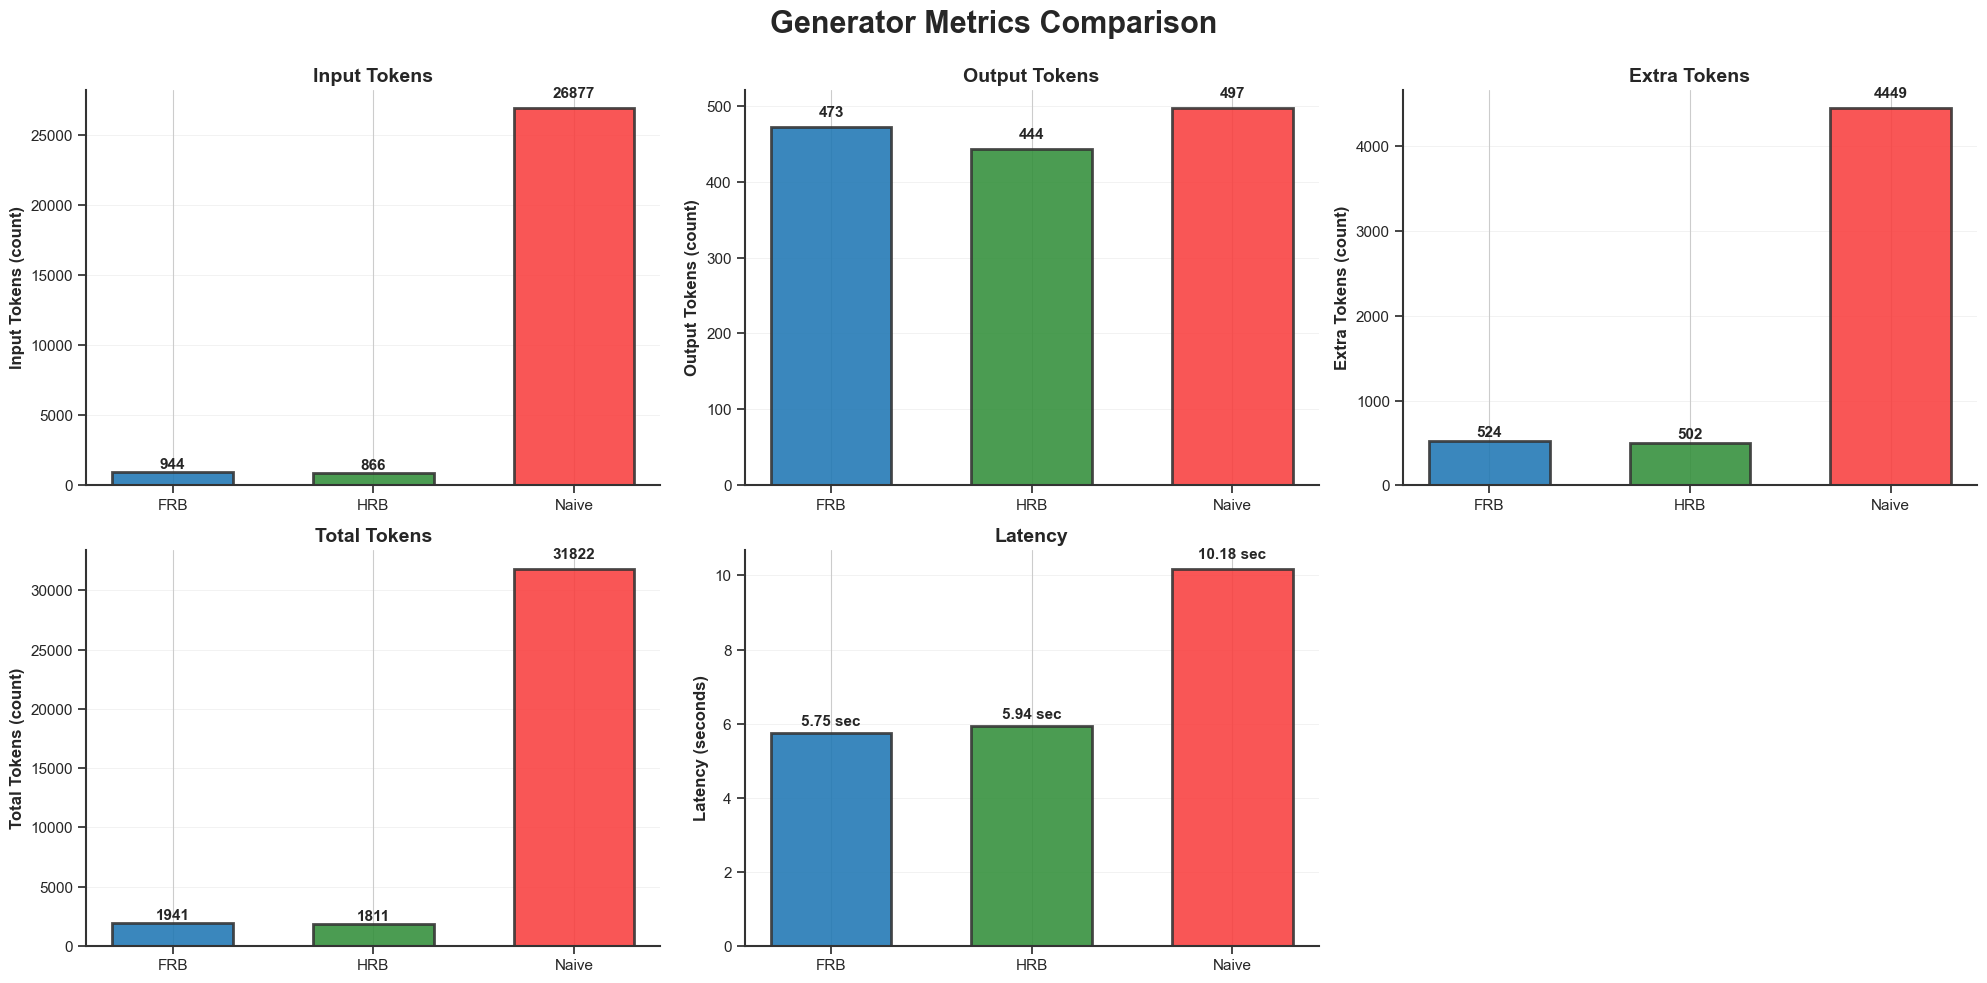

In [13]:
# Assuming router_usage_df and model_cmap are defined earlier in your script
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Generator Metrics Comparison', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        generator_usage_df['Model'],
        generator_usage_df[metric],
        color=[model_cmap[model] for model in generator_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[5].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

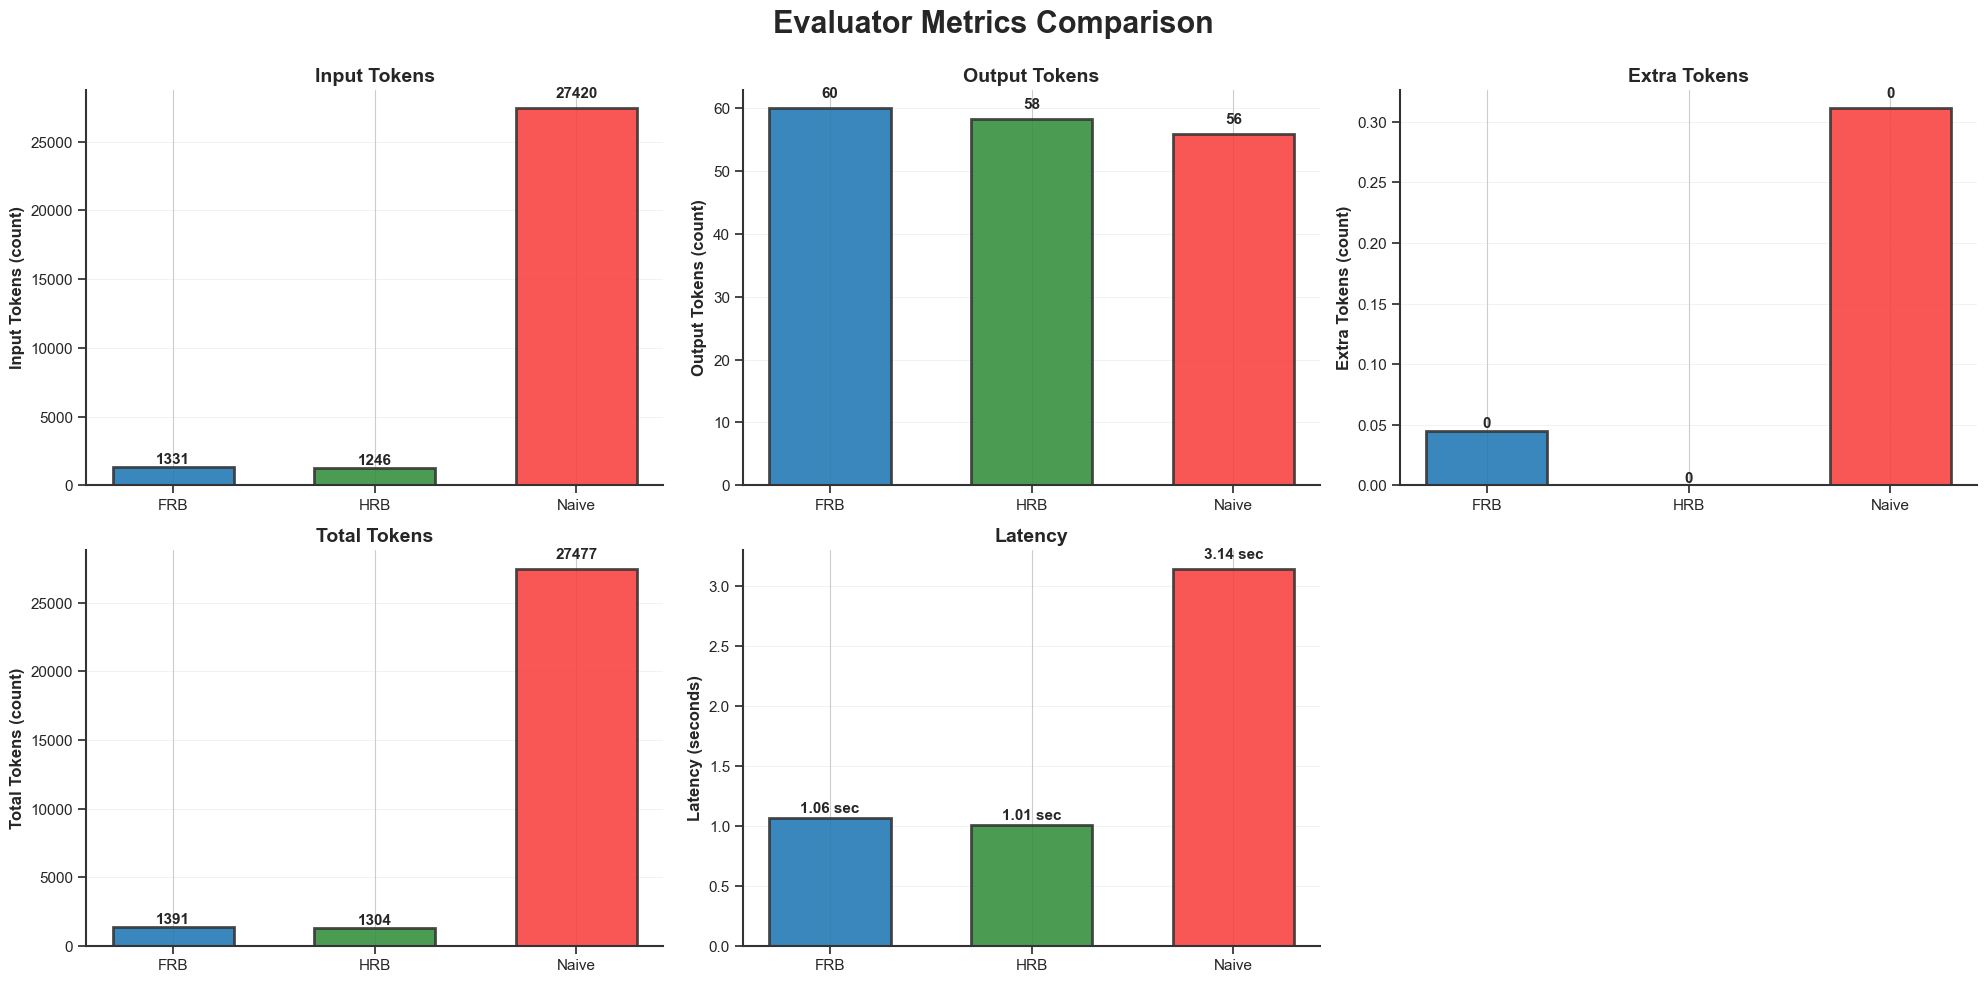

In [14]:
import matplotlib.pyplot as plt

# Assuming evaluator_usage_df and model_cmap are defined earlier in your script
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Latency']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Evaluator Metrics Comparison', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        evaluator_usage_df['Model'],
        evaluator_usage_df[metric],
        color=[model_cmap[model] for model in evaluator_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[5].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

In [15]:
naive_model_token_usage = step_analysis[step_analysis['Step']=="Generator_Naive"]
naive_model_token_usage

,Step,Model_x,Input Tokens,Output Tokens,Extra Tokens,Total Tokens,Model_y,Latency
5,Generator_Naive,Naive,26876.955556,496.711111,4448.511111,31822.177778,Naive,10.177333


<Axes: >

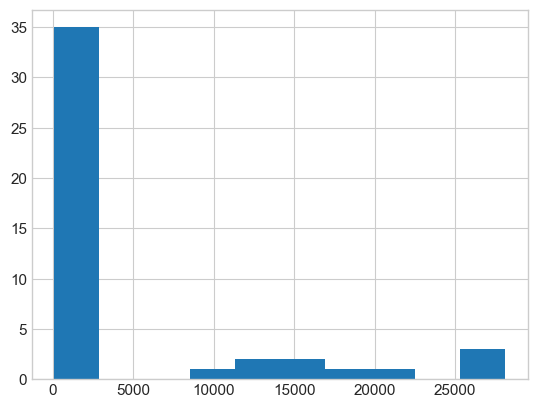

In [16]:
generator_naive = df[df['Step'] == 'Generator_Naive']
generator_naive['Extra Tokens'].hist()

# Used Plots


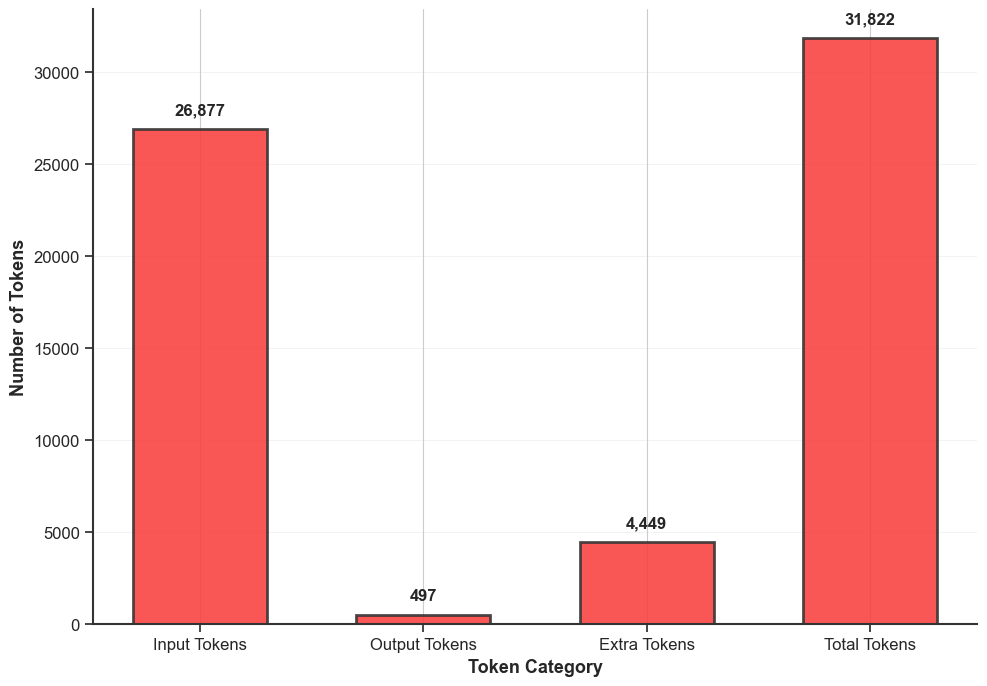

In [24]:
metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']
values = naive_model_token_usage[metrics].iloc[0].values

# Set academic style (il tuo formato)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
#fig.suptitle('Token Usage Breakdown for Naive Model Generator', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    metrics,
    values,
    color=model_cmap['Naive'],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Number of Tokens', fontsize=13, fontweight='bold')
ax.set_xlabel('Token Category', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

# Aggiunta dei valori sopra le barre
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height + (max(values) * 0.02), # Spaziatura proporzionale al valore massimo
        f'{height:,.0f}', # Formattazione intera con virgola per le migliaia (es. 54,274)
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()


fig.savefig('../plots/token_usage_naive.pdf', format='pdf', bbox_inches='tight')

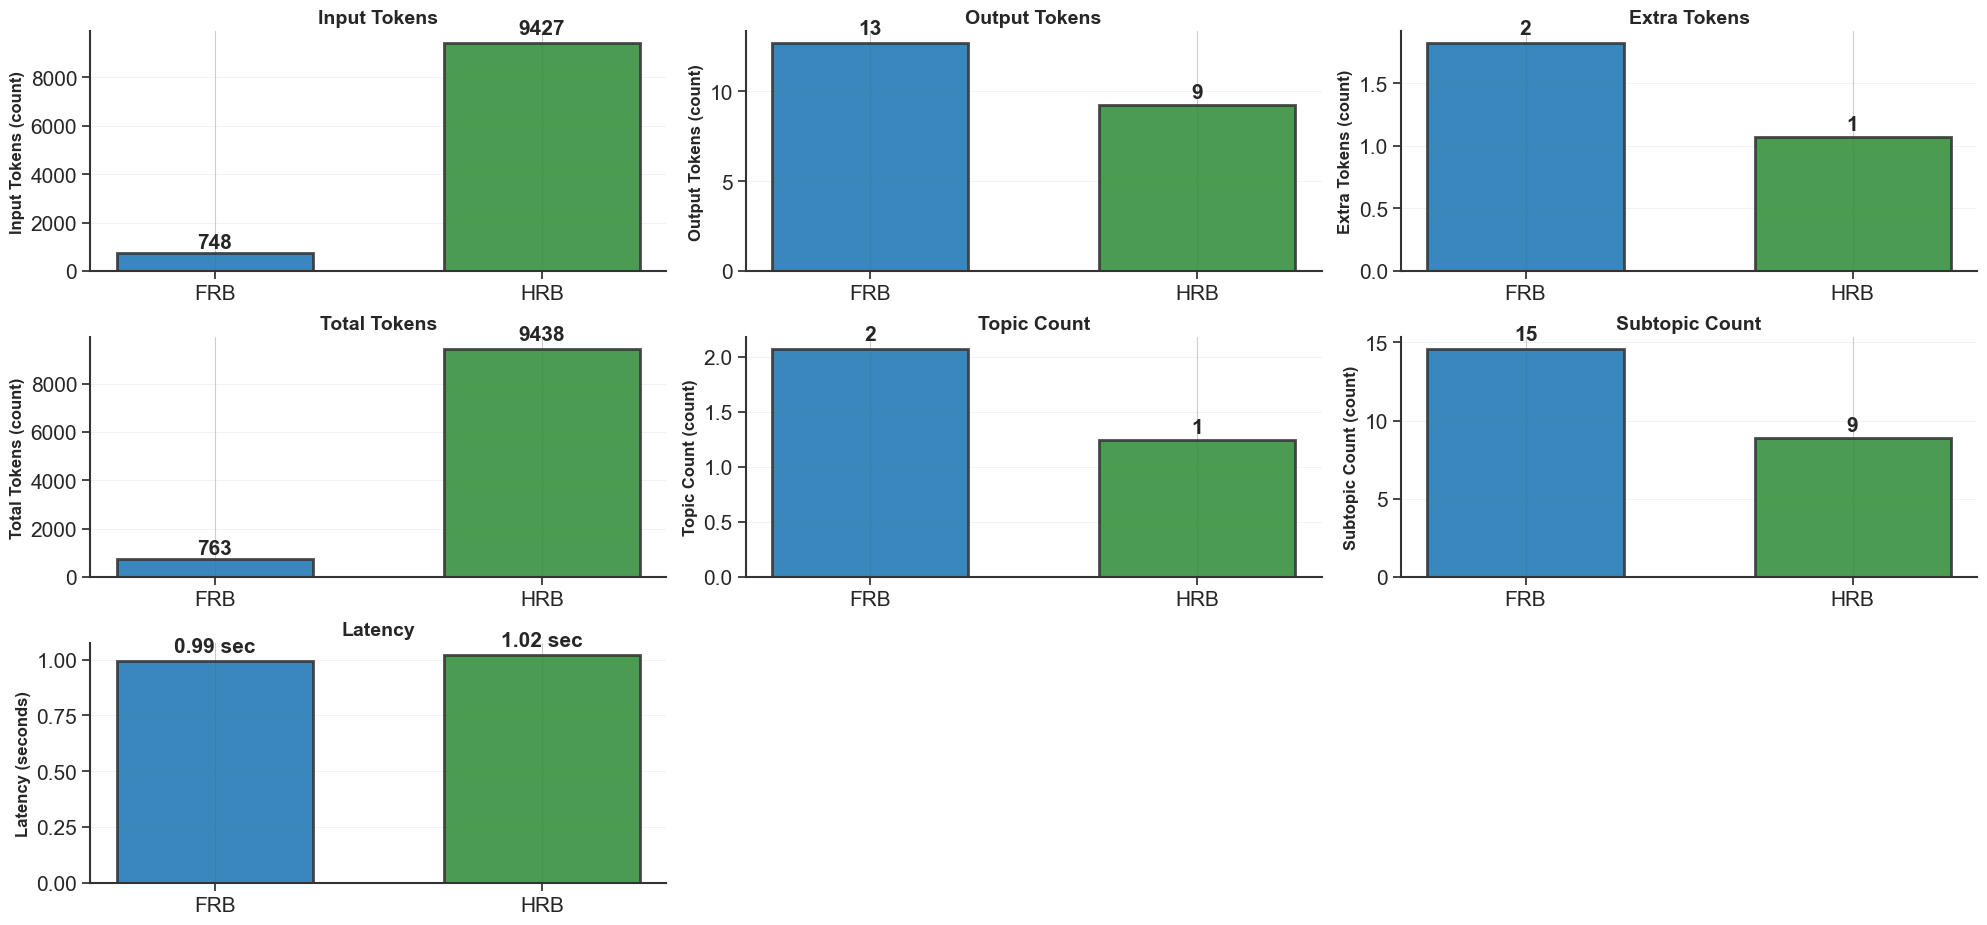

In [25]:
import matplotlib.pyplot as plt

# Assuming router_usage_df and model_cmap are defined earlier in your script
router_usage_df[['Topic Count', 'Subtopic Count']] = router_usage_df[['Topic_Count', 'Subtopic_Count']]
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens', 'Topic Count', 'Subtopic Count', 'Latency', 'Latency', 'Latency']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(3, 3, figsize=(20, 10))
#fig.suptitle('Router Metrics Comparison: Token Usage, Topic/Subtopic Counts and Latency', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        router_usage_df['Model'],
        router_usage_df[metric],
        color=[model_cmap[model] for model in router_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=15, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=15,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[7].set_visible(False)
axes[8].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

fig.savefig('../plots/router_metrics_comparison.pdf', format='pdf', bbox_inches='tight')

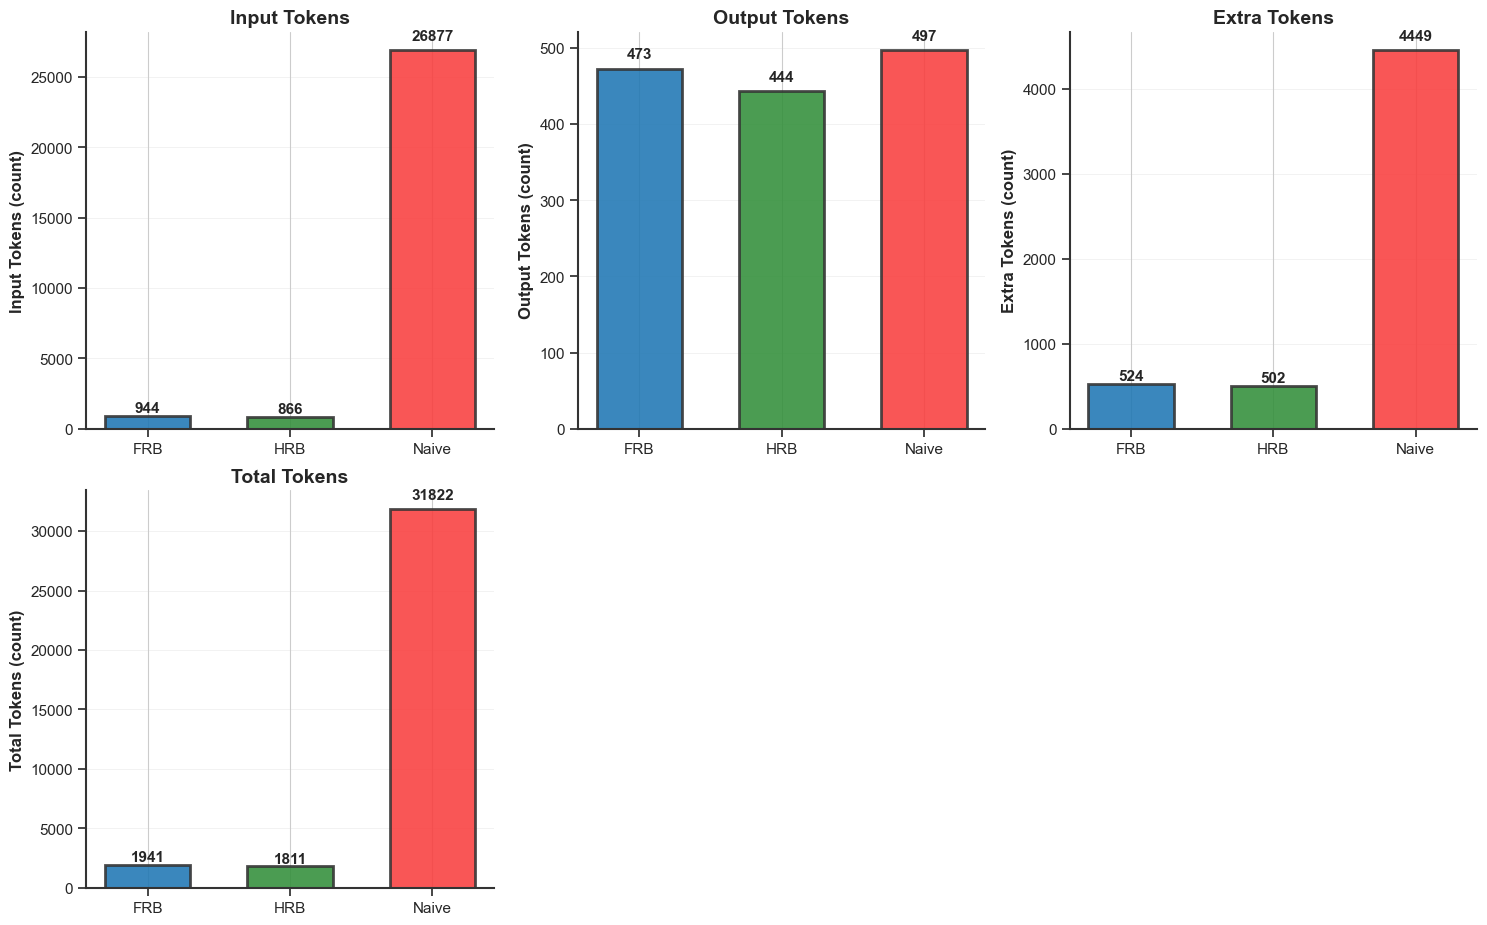

In [19]:
# Assuming router_usage_df and model_cmap are defined earlier in your script
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
#fig.suptitle('Generator Metrics Comparison', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        generator_usage_df['Model'],
        generator_usage_df[metric],
        color=[model_cmap[model] for model in generator_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[5].set_visible(False)
axes[4].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

fig.savefig('../plots/generator_token_metrics_comparison.pdf', format='pdf', bbox_inches='tight')

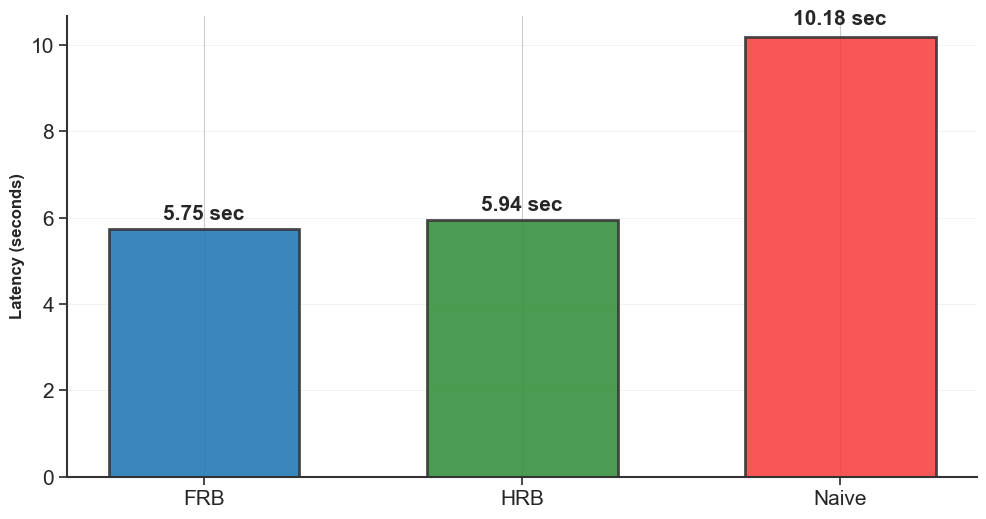

In [20]:
import matplotlib.pyplot as plt

# Assumiamo che router_usage_df e model_cmap siano già definiti
metrics_to_plot = ['Latency']
metric = metrics_to_plot[0]

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della figura (dimensioni ridotte per un singolo grafico)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Titolo aggiornato per essere coerente con la metrica analizzata
#fig.suptitle('Generator Models Comparison: Latency', fontsize=18, fontweight='bold', y=0.96)

# 5. Creazione del Bar Chart direttamente su 'ax'
bars = ax.bar(
    generator_usage_df['Model'],
    generator_usage_df[metric],
    color=[model_cmap[model] for model in generator_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

# Identificazione unità di misura
is_latency = (metric == 'Latency')
ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

# Configurazione assi e griglia
ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
#ax.set_title(f'Average {metric}', fontsize=18, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=15, length=6, width=1.2)

# Aggiunta delle etichette dei valori sopra le barre
for bar in bars:
    height = bar.get_height()
    
    text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
    
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02, # Spinge l'etichetta leggermente sopra la barra
        text_label,
        ha='center',
        va='bottom',
        fontsize=15,
        fontweight='bold'
    )

# Pulizia dei bordi (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.85) # Crea spazio sufficiente per il suptitle
plt.show()


fig.savefig('../plots/generator_latency_comparison.pdf', format='pdf', bbox_inches='tight')

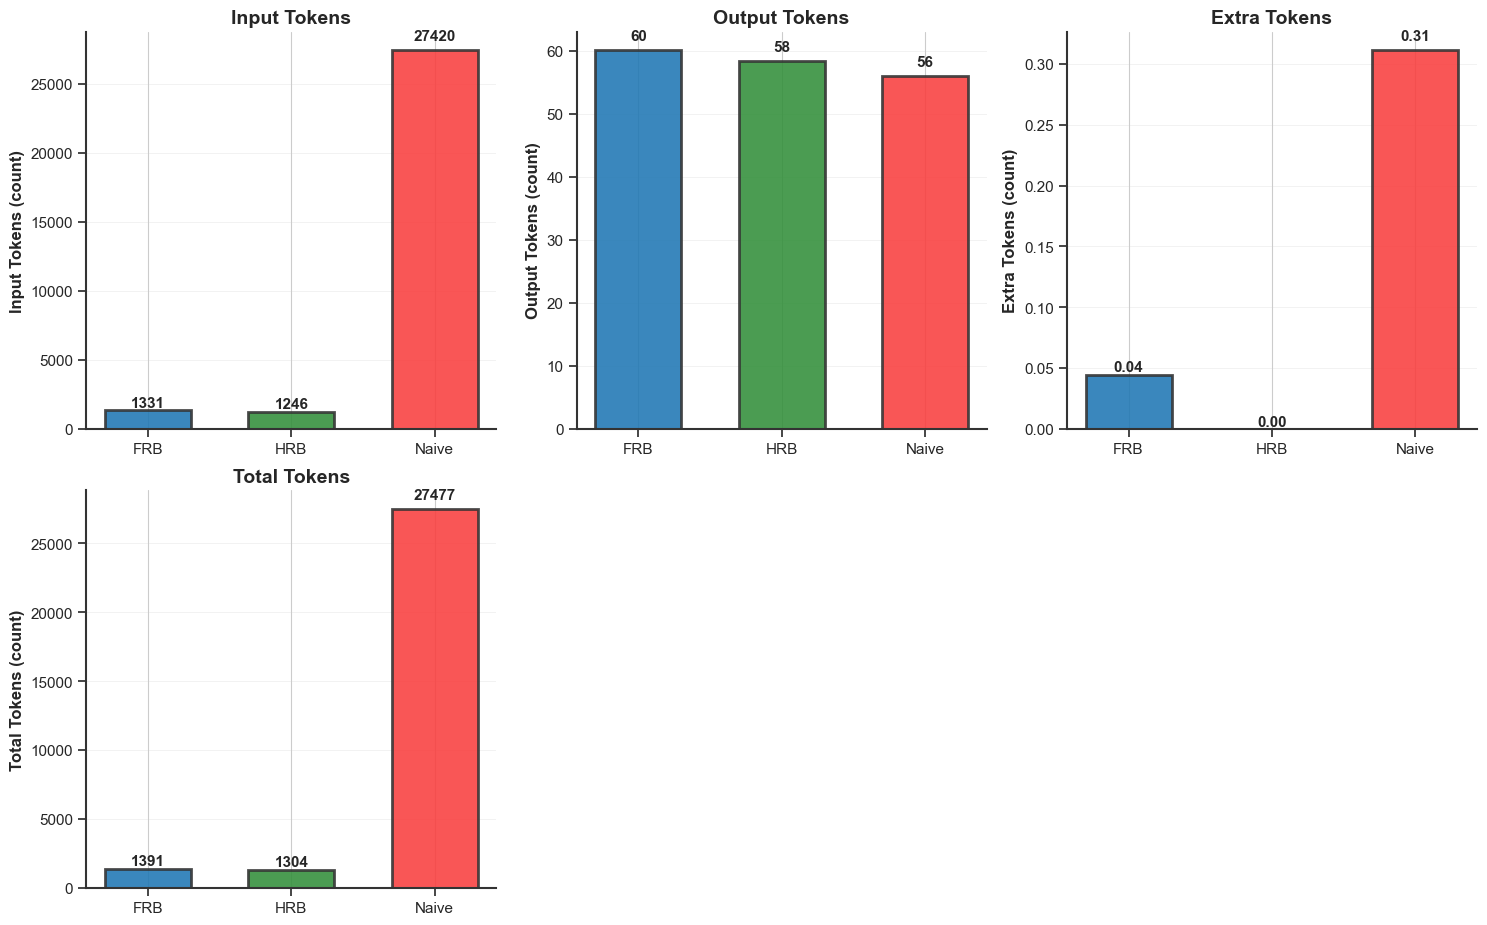

In [27]:
# Assuming router_usage_df and model_cmap are defined earlier in your script
metrics_to_plot = ['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della griglia di subplots (2 righe, 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
#fig.suptitle('Generator Metrics Comparison', fontsize=22, fontweight='bold', y=0.98)

# Appiattiamo l'array degli assi per iterare più facilmente 
axes = axes.flatten()

# 5. Iterazione su ogni metrica per creare il rispettivo subplot
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    bars = ax.bar(
        evaluator_usage_df['Model'],
        evaluator_usage_df[metric],
        color=[model_cmap[model] for model in evaluator_usage_df['Model']],
        edgecolor='#333333',
        linewidth=2,
        alpha=0.88,
        width=0.6
    )

    # Identificazione unità di misura
    is_latency = (metric == 'Latency')
    is_extra = (metric == 'Extra Tokens')
    ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

    # Configurazione assi e griglia
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

    # Aggiunta delle etichette dei valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        
        # CORRECTED: Format the text string inside the loop where 'height' exists
        text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}' if not is_extra else f'{height:.2f}'
        
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height * 1.02,
            text_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Pulizia dei bordi (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

# Nascondiamo il sesto subplot vuoto
axes[5].set_visible(False)
axes[4].set_visible(False)

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

fig.savefig('../plots/evaluator_token_metrics_comparison.pdf', format='pdf', bbox_inches='tight')

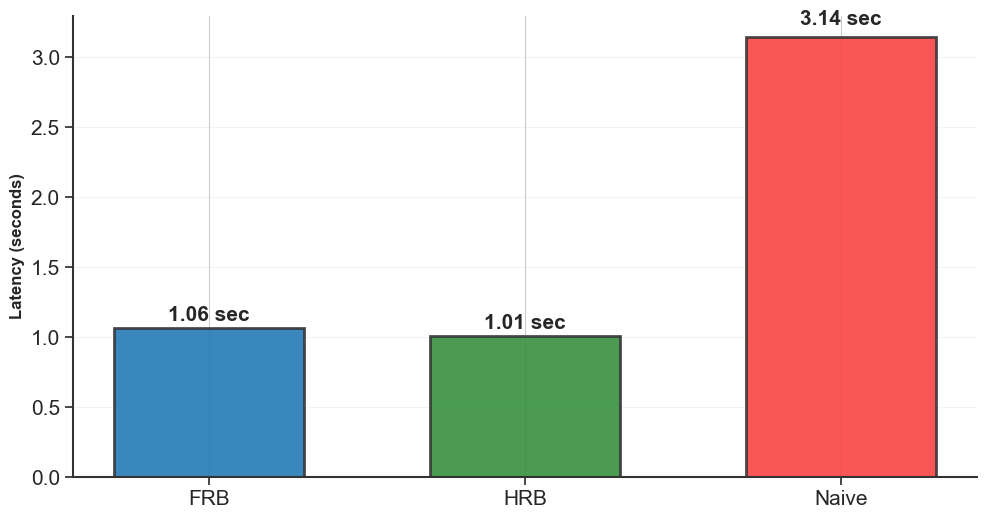

In [22]:
import matplotlib.pyplot as plt

# Assumiamo che router_usage_df e model_cmap siano già definiti
metrics_to_plot = ['Latency']
metric = metrics_to_plot[0]

# 3. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Creazione della figura (dimensioni ridotte per un singolo grafico)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Titolo aggiornato per essere coerente con la metrica analizzata
#fig.suptitle('Generator Models Comparison: Latency', fontsize=18, fontweight='bold', y=0.96)

# 5. Creazione del Bar Chart direttamente su 'ax'
bars = ax.bar(
    evaluator_usage_df['Model'],
    evaluator_usage_df[metric],
    color=[model_cmap[model] for model in evaluator_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

# Identificazione unità di misura
is_latency = (metric == 'Latency')
ylabel = f'{metric} (seconds)' if is_latency else f'{metric} (count)'

# Configurazione assi e griglia
ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
#ax.set_title(f'Average {metric}', fontsize=18, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=15, length=6, width=1.2)

# Aggiunta delle etichette dei valori sopra le barre
for bar in bars:
    height = bar.get_height()
    
    text_label = f'{height:.2f} sec' if is_latency else f'{height:.0f}'
    
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02, # Spinge l'etichetta leggermente sopra la barra
        text_label,
        ha='center',
        va='bottom',
        fontsize=15,
        fontweight='bold'
    )

# Pulizia dei bordi (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Layout e visualizzazione
plt.tight_layout()
plt.subplots_adjust(top=0.85) # Crea spazio sufficiente per il suptitle
plt.show()


fig.savefig('../plots/evaluator_latency_comparison.pdf', format='pdf', bbox_inches='tight')

C:\Users\murar\AppData\Local\Temp\ipykernel_24212\401451981.py:48: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "#". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  ax.bar(
C:\Users\murar\AppData\Local\Temp\ipykernel_24212\401451981.py:85: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "#". Passing invalid values is deprecated since 3.4 and will become an error in 3.11.
  Patch(facecolor='#888888', hatch=hatch_map['Generator'], edgecolor='#333333', label='Generator Token'),


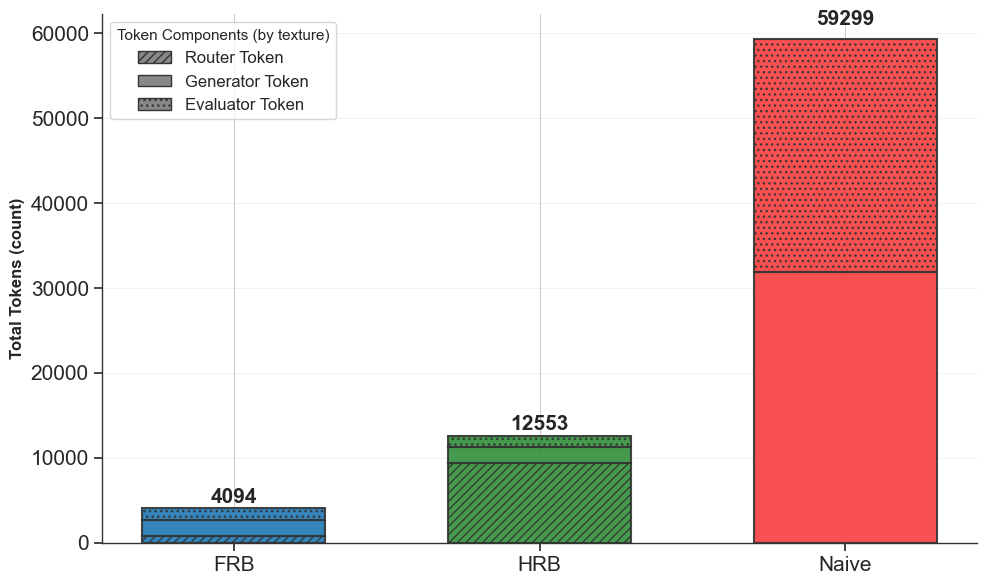

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Estraggo le colonne che ti interessano (uso .copy() per evitare SettingWithCopyWarning)
df = step_analysis[['Step', 'Model_x', 'Total Tokens', 'Latency']].copy()

# 1. CORREZIONE FONDAMENTALE: Creiamo la colonna 'Component' pulita
df['Component'] = df['Step'].apply(lambda x: x.split('_')[0])

# Ora facciamo il pivot sulla colonna pulita, non su 'Step'
pivot_df = df.pivot(index='Model_x', columns='Component', values='Total Tokens').fillna(0)

# Ordine dei modelli
models_order = ['FRB', 'HRB', 'Naive']
pivot_df = pivot_df.reindex(models_order)

# Componenti e texture
components = ['Router', 'Generator', 'Evaluator']

hatch_map = {
    'Router': '////',
    'Generator': '###',
    'Evaluator': '...'
}

# 2. Setup dello stile accademico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# 3. Creazione della figura
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# 4. Creazione dello Stacked Bar Chart
bottom = np.zeros(len(models_order))

# --- 5. Creazione dello Stacked Bar Chart con Colore per Modello e Tratteggio per Step ---
for i, model in enumerate(models_order):
    model_color = model_cmap[model] # Assumiamo che model_cmap sia definita prima
    
    for j, component in enumerate(components):
        value = pivot_df.loc[model, component]
        
        ax.bar(
            model,            
            value,            
            bottom=bottom[i], 
            color=model_color, 
            hatch=hatch_map[component], 
            edgecolor='#333333',        
            linewidth=1.5,
            alpha=0.9,
            width=0.6,
            label=f"{model} - {component}" if i == 0 else "" 
        )
        bottom[i] += value

# --- 6. Finalizzazione del Grafico ---
metric = 'Total Tokens'
ylabel = f'{metric} (count)'

ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=15, length=6, width=1.2)

# Etichette TOTALI sopra le barre
for i, model in enumerate(models_order):
    total_height = bottom[i]
    ax.text(i, total_height * 1.02, f'{total_height:.0f}', ha='center', va='bottom', fontsize=15, fontweight='bold')

# Pulizia dei bordi
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# --- 7. Gestione della Legenda ---
legend_elements = [
    Patch(facecolor='#888888', hatch=hatch_map['Router'], edgecolor='#333333', label='Router Token'),
    Patch(facecolor='#888888', hatch=hatch_map['Generator'], edgecolor='#333333', label='Generator Token'),
    Patch(facecolor='#888888', hatch=hatch_map['Evaluator'], edgecolor='#333333', label='Evaluator Token')
]
ax.legend(handles=legend_elements, fontsize=12, loc='upper left', frameon=True, title="Token Components (by texture)")

plt.tight_layout()
plt.show()

fig.savefig('../plots/e2e_token_comparison.pdf', format='pdf', bbox_inches='tight')